# The Fed cycle, reconstructed from money market filings

Every money market fund reports its seven day gross yield on each
monthly N-MFP2 filing. Stack those across every prime fund and you get
a monthly panel of short rates straight out of regulatory filings: the
zero era, the 2022-23 hiking cycle, and the plateau, with
cross-sectional statistics no single rate series can give you.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import datetime as dt

import pandas as pd

from py3spread import Client

client = Client(max_retries=8)  # long pull, ride through the per-minute rate limit

# discover currently active prime funds, then pull each registrant's
# full monthly filing history
end = dt.date.today()
recent = client.money_market_funds.iter(
    money_market_fund_category="Prime",
    accepted_start=str(end - dt.timedelta(days=90)), accepted_end=str(end))
registrants = sorted({r["cik"] for r in recent})
print(f"{len(registrants)} registrants with active prime funds")

panel = []
for cik in registrants:
    for r in client.money_market_funds.iter(
        cik=cik, accepted_start="2021-01-01", accepted_end=str(end)):
        if r["money_market_fund_category"] != "Prime" or not r["seven_day_gross_yield"]:
            continue
        if r["period_of_report"] < "2021-01-01":
            continue  # amendments reach back before the panel window
        panel.append({
            "month": r["period_of_report"][:7],
            "series": r["series_id"],
            "fund": r["series_name"],
            "yield_pct": float(r["seven_day_gross_yield"]) * 100,
        })

df = pd.DataFrame(panel).drop_duplicates(subset=["month", "series"], keep="last")

# funds winding down report near-zero yields that are not market signal
med = df.groupby("month")["yield_pct"].transform("median")
outliers = (df["yield_pct"] - med).abs() > 3
if outliers.any():
    print(f"excluded {outliers.sum()} fund-month outliers more than 3 points"
          " from the monthly median (wind-downs and reporting artifacts)")
df = df[~outliers]
print(f"{len(df)} fund-month observations, {df['series'].nunique()} funds,"
      f" {df['month'].min()} to {df['month'].max()}")

35 registrants with active prime funds


excluded 105 fund-month outliers more than 3 points from the monthly median (wind-downs and reporting artifacts)
2201 fund-month observations, 61 funds, 2021-01 to 2024-05


## The cycle

Median prime fund yield with the 10th-90th percentile band. Months with
fewer than eight reporting funds are dropped so thin coverage cannot
masquerade as market signal.

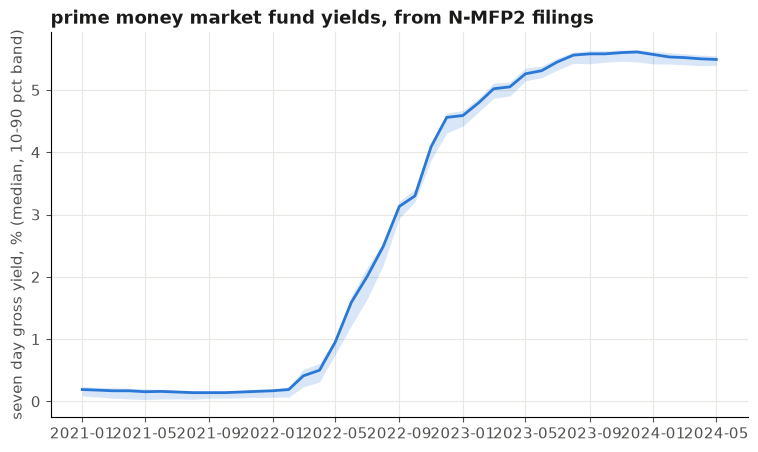

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


counts = df.groupby("month")["series"].nunique()
good_months = counts[counts >= 8].index
sample = df[df["month"].isin(good_months)]

stats = sample.groupby("month")["yield_pct"].quantile([0.1, 0.5, 0.9]).unstack()
x = pd.to_datetime(stats.index)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(x, stats[0.1], stats[0.9], color=BLUE, alpha=0.18, linewidth=0)
ax.plot(x, stats[0.5], color=BLUE, linewidth=2)
ax.set_title("prime money market fund yields, from N-MFP2 filings",
             loc="left", fontweight="bold")
ax.set_ylabel("seven day gross yield, % (median, 10-90 pct band)")
plt.show()

## Who passes rate moves through fastest

Regress each fund's monthly yield change on the market median change
(ordinary least squares, plain numpy). Beta near 1 means the fund
tracks the cycle one for one; low beta with low R-squared means yields
that move to their own drummer, worth a closer look.

In [3]:
import numpy as np

market = sample.groupby("month")["yield_pct"].median()
d_market = market.diff().dropna()

results = []
for series, grp in sample.groupby("series"):
    y = grp.set_index("month")["yield_pct"].reindex(market.index)
    dy = y.diff()
    both = pd.concat([dy, d_market], axis=1, keys=["fund", "mkt"]).dropna()
    if len(both) < 24:
        continue
    X = np.column_stack([np.ones(len(both)), both["mkt"].values])
    coef, res, *_ = np.linalg.lstsq(X, both["fund"].values, rcond=None)
    ss_tot = ((both["fund"] - both["fund"].mean()) ** 2).sum()
    r2 = 1 - (res[0] / ss_tot if len(res) and ss_tot else 0)
    results.append({"fund": grp["fund"].iloc[-1], "beta": coef[1],
                    "r2": r2, "months": len(both)})

betas = pd.DataFrame(results).sort_values("beta")
print(f"{len(betas)} funds with 24+ months of history")
print(f"median pass-through beta: {betas['beta'].median():.2f}")
pd.concat([betas.head(5), betas.tail(5)]).style.format(
    {"beta": "{:.2f}", "r2": "{:.2f}"}).hide(axis="index")

49 funds with 24+ months of history
median pass-through beta: 1.01


fund,beta,r2,months
None,0.82,0.85,40
None,0.83,0.85,40
None,0.83,0.85,40
None,0.83,0.86,40
None,0.83,0.90,38
None,1.05,0.98,40
None,1.05,0.95,40
None,1.05,0.95,40
None,1.06,0.97,40
None,1.08,0.86,40


## Dispersion tells its own story

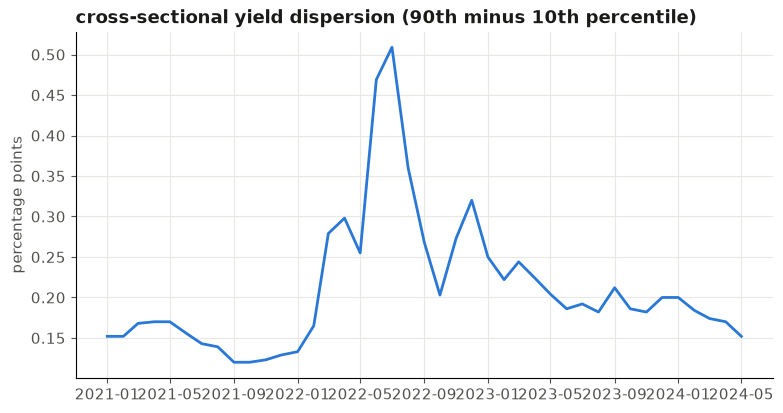

In [4]:
spread = (sample.groupby("month")["yield_pct"]
          .agg(lambda s: s.quantile(0.9) - s.quantile(0.1)))

fig, ax = plt.subplots()
ax.plot(pd.to_datetime(spread.index), spread.values, color=BLUE, linewidth=2)
ax.set_title("cross-sectional yield dispersion (90th minus 10th percentile)",
             loc="left", fontweight="bold")
ax.set_ylabel("percentage points")
plt.show()

Dispersion compresses when rates sit still and blows out when the Fed
moves, because funds pass hikes through at different speeds: the same
effect the beta table ranks fund by fund.

Caveats, honestly: funds enter and leave the panel (prime fund closures
were common in this window), the seven day gross yield is before fees,
and months are filing periods rather than calendar averages. The panel
currently runs through May 2024: the SEC amended Form N-MFP in June
2024 and the yield field mapping for the new schema is on the 3spread
roadmap, so the recent cutting cycle will fill in as that lands. The
point is the ceiling: a complete short-rate panel, fund by fund and
month by month, out of a free filings API.